# Factor PCA {#sec-pca}

Now we need to get the principal components of the Fama-French 6 factors.

Standard PCA suffers from:

- **Curse of dimensionality:** Estimating covariance matrices for large cross-sections requires long time horizons to avoid singularity.
- **Non-stationarity:** The hypothesis of a constant covariance matrix across time can be too strong in some scenarios, including this one.
- **Non-linearities:** PCA on a single covariance matrix, a linear measure of relationships, for the whole process cannot properly capture non-linear relationships.

Here we apply @AitSahalia2015, which uses high-frequency data to estimate spot covariance matrices and their principal components. With it, we relax the stationarity assumptions needed and approximate non-linear relationships given Itô's Lemma.

The following math and commentary are largely taken as-is from the paper. First, we present the theory, then the implementation in Python, and finally the results.

## Methodology

### Dynamics of the variable

The $d$-dimensional (in our case $d = 6$) process $X$ of the factors is a general Itô-semimartingale, defined on a filtered probability space:

$$
    X_t = X_0 + \int_0^t b_s ds + \int_0^t \sigma_s dW_s + J_t \tag{2}
$$

- $X_t$ is the $d$-dimensional log-price (or cumulative factor) process.
- $b_s$ is the $d$-dimensional locally bounded drift vector.
- $\sigma_s$ is the spot volatility matrix, linking to the spot covariance via $c_s = \sigma_s \sigma_s^T$.
- $W_s$ is a $d$-dimensional standard Brownian motion.
- $J_t$ is a pure jump process accounting for discrete anomalous shocks. (More information in the paper).

### Parameters of interest

The PCA goal is to find instantaneous linear combinations of $X$, orthogonal to each other, that maximize some measure of variation. In the paper's case, the continuous part of the quadratic variation.

Let $\mathcal{M}^+_d$ denote the set of $d \times d$ positive semi-definite symmetric matrices. For any $A \in \mathcal{M}^+_d$, we define:

- The $d$-dimensional vector of its eigenvalues sorted in non-increasing order: $\lambda(A) = \left(\lambda_1(A), \lambda_2(A), \dots, \lambda_d(A)\right)^T$.
- The eigenvector corresponding to the $g$-th eigenvalue $\lambda_g(A)$ as $\gamma_g(A)$, which satisfies: $A\gamma_g = \lambda_g \gamma_g$ and $\gamma_g^T \gamma_g = 1$.

Our interest is calculating the $T \times d$ matrix of principal components, where $T$ is the total number of (high-frequency) observations. This is related to the paper's derivation of the integrated/realized principal component of the $g$-th eigenvalue $\lambda_g$, $\int_0^t \gamma_{g,s-}^T dX_s$.

The paper focuses on the estimation of the realized eigenvalues ($\int_0^t \lambda_s ds$) and eigenvectors ($\int_0^t \gamma_{g,s} ds$), while deriving their asymptotic properties and bias corrections. We focus on the PCs, but at @sec-pca-app we summarize the assumptions for the asymptotic properties and the unused estimators.

### Principal components estimator

#### Spot covariance matrix

The first step for all is estimating a spot covariance matrix and its associated eigenvalues. To capture non-stationary dynamics, the time window $[0, t]$ in increments of $\Delta_n$ is divided into non-overlapping blocks of length $k_n \Delta_n$. Within each small block, the continuous covariance $c_s$ is assumed to be roughly constant. By dynamically estimating instantaneous matrices and summing them, the procedure continuously adapts to shifting correlations, capturing non-linearities without requiring global parameter estimates.

At each $i k_n \Delta_n$, we estimate $c_{i k_n \Delta_n}$ using the block spot covariance estimator $\hat{c}_{i k_n \Delta_n}$ defined as:

$$
    \hat c_{ik_n}\Delta_n = \frac{1}{k_n\,\Delta_n} \sum_{j=1}^{k_n} \left(\Delta_{ik_n+j}^{n}X\right)\left(\Delta_{ik_n+j}^{n}X\right)^{T} \mathbf{1}\left\{\left\|\Delta_{ik_n+j}^{n}\right\|\le u_n\right\} \tag{5}
$$

Where the return increment is: $\Delta_l^n X = X_{l \Delta_n} - X_{(l-1)\Delta_n}$, and $u_n$ is the jump truncation threshold. The $k$ and $u$ parameters can be chosen with the shorthands proposed by the literature:

- **Block Size ($k_n$):** the divisor of $[t / \Delta_n]$ closest to $\theta \Delta_n^{-1/2} \sqrt{\log(d)}$, with $\theta = 0.5$. Other choices of $\theta$ and functions of $d$ deliver similar results. It scales inversely with the sampling frequency ($\Delta_n$) and grows slightly with dimensionality ($d$) to ensure stable covariance estimates without smoothing over true time-varying dynamics.
- **Jump Truncation ($u_{i, n}$):** Set asset-by-asset as $u_{i,n} = 3\left(\int_{0}^{t}c_{ii,s}ds/t\right)^{0.5}\Delta^{0.47}_{n}$. Where the internal integral can be estimated with Bipower Variation. This removes discrete jumps while preserving continuous diffusion.

The instantaneous eigenvalues $\hat{\lambda}_{i k_n \Delta_n} = \lambda(\hat{c}_{i k_n \Delta_n})$ are obtained from the standard determinant equation:

$$
    \operatorname{det}(\hat{c}_i - \hat{\lambda} \mathbb{I}) = 0 
$$


#### Integrated principal component

The paper focuses on the integrated principal components, whose estimator is defined as:

$$
    \widehat{PC}_{g} = \sum_{i=1}^{[t/(k_n\Delta_n)]-1}\hat{\gamma}^{T}_{g,(i-1)k_n\Delta_n}\left(X_{(i+1)k_n\Delta_n}-X_{ik_n\Delta_n}\right) \tag{\text{Proposition 3}}
$$

Because the estimator is a stochastic integral, the weight errors are uncorrelated with the forward returns. The estimation noise naturally cancels out, removing the need for a Hessian bias correction. PCs use the eigenvectors estimated from the immediately preceding block to project the current block's returns, ensuring that our dynamic portfolio weights are strictly "adapted" (determined in-sample before trading) and free from microscopic look-ahead bias.

However, we want a $T \times d$ matrix of principal components, not just the integrated one. So we basically do not want to run the summation and instead store the intermediate results. The pseudocode below outlines the algorithm.


### Estimation algorithm

To estimate the $T \times d$ matrix of principal components, we must project each individual high-frequency return observation onto the previous block's eigenvector. The Pascal-like pseudocode below outlines the procedure.

This code was written in matrix form, as it will be a much more effective way to implement in Python. Still, it should be equivalent to the original paper's algorithm.

```pascal
procedure pca_high_freq(
    X : Matrix;            // Shape: (T, d) | high-frequency return matrix
    k : Integer;           // Scalar        | observations per block
    u : Matrix;            // Shape: (d,)   | jump truncation thresholds
    evectors_prev : Matrix // Shape: (d, d) | initial eigenvectors
);

    // 1. Parameter Setup & Initialization
    T = number of rows in X
    d = number of cols in X
    Delta = 1 / T
    N = Floor(T / k) // Total number of full blocks

    // Initialize empty arrays to store outputs:
    PC = empty Matrix of size T x d
    E_vals = empty Matrix of size N x d
    E_vecs = empty Matrix of size N x d x d

    // 2. Process Data Block by Block
    for i = 0 to N - 1 do
    begin
        // Define the current block
        block_start = i * k
        block_end = (i + 1) * k
        X_block = X[block_start to block_end]

        // Calculate PCs for the current block using the previous eigenvectors:
        PC[block_start to block_end] = X_block * evectors_prev

        // Truncate X with boolean mask and calculate the spot covariance matrix:
        X_trunc := X_block * (Abs(X_block) <= u)
        cov_spot = (Transpose(X_trunc) * X_trunc) / (k * Delta)

        // Eigen decomposition:
        evalues, evectors = eigen decomposition of cov_spot, descending evalues

        // Store results and update eigenvectors for the next block:
        E_vals[i, :] = evalues
        E_vecs[i, :, :] = evectors
        evectors_prev = evectors 
    end;

    // 3. Handling the last block if (T % k != 0)
    block_start = N * k
    if block_start < T then
    begin
        X_block = X[block_start to T]
        PC[block_start to T] = X_block * evectors_prev
    end;

    return PC, E_vals, E_vecs
end;
```

### Specifics of our setup

We implement the above algorithm for the Fama-French 6 factors. One important thing to note is that we treat the timeline with gaps on non-business days, non-trading hours, and the removed 9:30 return as a continuous timeline for the PCA. While this is standard, it is still important to note.

In our case, $t$ was normalized to 1. We thus have $T$ minute-level observations in the interval $[0, t]$, spanning the whole time series window. The same is true for the 5-minute-level exercise (with a different $T$ value).

## Code implementation

Here we implement the algorithm described above in Python.

First the setup, with debugging:

In [1]:
%reset -f
import importlib

And core modules:

In [2]:
#| output: false
import os
if os.path.basename(os.getcwd()) == "src": os.chdir("..")

import polars as pl
import numpy as np

from tqdm import tqdm

from numpy.typing import NDArray

import src.utils as ut
import src.graphs as plot
from src.parameters import PARAMETERS as PARS
importlib.reload(ut)
importlib.reload(plot)

ut.set_seed()

First, we implement the rules of thumb used in the literature to set the parameters $k$ and $u$:

In [3]:
def default_k(d: int, T: int, Delta: float) -> int:
    theta = 0.5

    k_target = int(np.round(theta * (Delta**-0.5) * np.sqrt(np.log(d))))
    divisors = np.array([i for i in range(1, T + 1) if T % i == 0])
    closest_idx = np.argmin(np.abs(divisors - k_target))

    return int(divisors[closest_idx])

def default_u(X: NDArray, T: int, Delta: float) -> NDArray:
    X_abs = np.abs(X)
    bpv = (np.pi / 2) * np.sum(X_abs[1:] * X_abs[:-1], axis = 0)
    u = 3 * np.sqrt(bpv / 1) * (Delta ** 0.47) # bpv/1: $t$ normalized to 1
    return u

Then, to start the PCA algorithm, we need to estimate the first block's eigenvectors. We can use the warm-up data selected in [src/data_factors.ipynb](src/data_factors.ipynb) / @sec-factors to achieve that. Otherwise, the first block would be left with `np.nan`.

In [4]:
def pca_start_evectors(
    X: NDArray, k: int | None = None, u: NDArray | None = None,
    quiet: bool = True
) -> NDArray:
    ut.pca_high_freq_validate(X, k, u, None)

    T: int = X.shape[0]
    d: int = X.shape[1]
    Delta: float = 1 / T

    if k is None:
        k = default_k(d, T, Delta)
        if not quiet: print(f"Calculated `k` as {k}.")
    if u is None:
        u = default_u(X, T, Delta)
        if not quiet: print(f"Calculated `u` as {u}.")

    _, evectors = pca_truncated(X, k * Delta, u)

    return evectors

Finally, we implement the main algorithm. First, the simple PCA with truncation engine, for the stationary data within each block:

In [5]:
def pca_truncated(
    X: NDArray, # Shape: (k, d) a block of the original X
    n: float, # k * Delta
    u: NDArray # Shape: (d,)
):
    X_trunc = X * (np.abs(X) <= u) # x*0 for big values, else x*1
    cov_spot = (X_trunc.T @ X_trunc) / n # No need to demean following the paper

    evalues, evectors = np.linalg.eigh(cov_spot)
    evalues_order = np.argsort(evalues)[::-1]

    return evalues[evalues_order], evectors[:, evalues_order]

Then, the main loop that iterates over the blocks, runs the PCA, and stores results:

In [ ]:
def pca_high_freq_core(
    N: int, k: int, T: int, Delta: float,
    u: NDArray, # Shape: (d,)
    X: NDArray, # Shape: (T, d)
    evectors_prev: NDArray, # Shape: (d, d)
    PC: NDArray, # Shape: (T, d)
    E_vals: NDArray, # Shape: (N, d)
    E_vecs: NDArray, # Shape: (N, d, d)
    quiet: bool = False
):
    for i in tqdm(range(N), total = N, disable = quiet): # Last block after loop
        block_start, block_end = i * k, (i + 1) * k

        X_block = X[block_start:block_end, :]

        PC[block_start:block_end, :] = X_block @ evectors_prev

        evalues_prev, evectors_prev = pca_truncated(X_block, k * Delta, u)
        E_vals[i, :] = evalues_prev
        E_vecs[i, :, :] = evectors_prev

    block_start = N * k
    if block_start < T:
        X_block = X[block_start:T, :]
        PC[block_start:T, :] = X_block @ evectors_prev

    return PC, E_vals, E_vecs

Finally, the main orchestrator that validates the inputs, sets the default parameters, and runs the main loop:

In [7]:
def pca_high_freq(
    X: NDArray, # Shape: (T, d)
    k: int | None = None,
    u: NDArray | None = None, # Shape: (d,)
    evectors_start: NDArray | None = None, # Shape: (d, d)
    quiet: bool = False
) -> dict[str, NDArray]:
    # Setup:
    ut.pca_high_freq_validate(X, k, u, evectors_start)
    X.flags.writeable = False

    T: int = X.shape[0] # Number of observations (rows)
    d: int = X.shape[1] # Number of variables (columns)
    Delta: float = 1 / T

    if k is None:
        k = default_k(d, T, Delta)
        if not quiet: print(f"Calculated `k` as {k}.")
    if u is None:
        u = default_u(X, T, Delta)
        if not quiet: print(f"Calculated `u` as {u}.")

    # Warm up:
    N: int = T // k # Number of blocks - 1
    if evectors_start is None:
        evectors_prev = np.full((d, d), np.nan)
    else:
        evectors_prev = evectors_start # Shape: (d, d)

    PC = np.full((T, d), np.nan) # Shape: (T, d)
    E_vals = np.full((N, d), np.nan) # Shape: (N, d)
    E_vecs = np.full((N, d, d), np.nan) # Shape: (N, d, d)

    # Main loop:
    if not quiet: print(f"Starting PCA with {N} blocks of size {k}.")
    PC, E_vals, E_vecs = pca_high_freq_core(
        N = N, k = k, T = T, Delta = Delta, u = u,
        X = X, evectors_prev = evectors_prev,
        PC = PC, E_vals = E_vals, E_vecs = E_vecs,
        quiet = quiet
    )

    return {"pc": PC, "evalues": E_vals, "evectors": E_vecs}

Some performance considerations:

- The `pca_high_freq_core()` must be run sequentially.
- Given the low dimensionality of the factor data, using GPU with e.g. `cupy` would add unnecessary overhead. Still, the code could be translated basically as-is with `import cupy as np` instead.
- It could be beneficial to lock multithreading of NumPy's BLAS/LAPACK matrix engines.
- Ensuring that `X` is a contiguous array in memory could help performance.
- Finally, the code could be just-in-time compiled with `numba`, and the separation of `pca_high_freq_core()` helps with that. One would only need to decorate it with `@numba.jit`.

The code runs super fast, so the suggestions above are not necessary.

## Calculating the PCA

### Loading data

First, I load the data processed in [src/data_factors.ipynb](src/data_factors.ipynb) / @sec-factors.

In [8]:
blocks_size = {1: 858, 5: 384}

data_raw = {
    1: pl.read_csv("data/factors_1min_returns.csv"),
    5: pl.read_csv("data/factors_5min_returns.csv")
}

data_raw = {
    min: df.with_columns(
        pl.col("datetime").str.strptime(pl.Datetime, format = "%Y-%m-%d %H:%M")
    )
    for min, df in data_raw.items()
}

cols_fct = {
    "ff__mkt": "market",
    "ff__smb": "size",
    "ff__hml": "value",
    "ff__rmw": "proftability",
    "ff__cma": "investment",
    "ff__umd": "momentum",
}

Then, we separate the added warm-up data from the main part from which we want the PCs:

In [9]:
data_warmup = {
    min: (
        df
        .filter(pl.col("datetime").dt.date() < PARS.date_start.item())
        [list(cols_fct.keys())]
        .to_numpy()
    )
    for min, df in data_raw.items()
}

data_main = {
    min: df.filter(pl.col("datetime").dt.date() >= PARS.date_start.item())
    for min, df in data_raw.items()
}

### Running algorithm

First, let us inspect the default $k$ and $u$ parameters that will be generated. It only cuts the higher quantiles of the data.

In [19]:
pca_start_evectors(data_main[1][list(cols_fct.keys())].to_numpy(), quiet = False)
u_default = [0.00182358, 0.0012769,  0.00082141, 0.00055697, 0.00055211, 0.00102862]

print("\nCalculated `u` and quantiles of the absolute factors:")
(
    pl.concat(
        [
            pl.DataFrame({
                col: val * 100 for col, val in zip(cols_fct.keys(), u_default)
            })
        ] + [
            data_main[1].select(cols_fct.keys()).select(pl.all().abs().quantile(q) * 100)
            for q in [0.995, 0.99, 0.5]
        ]
    )
    .with_columns(
        statistic = pl.Series(["u"] + [f"factor's Q{q}" for q in [0.995, 0.99, 0.5]])
    )
    .select(["statistic"] + list(cols_fct.keys()))
    .rename(cols_fct)
)

Calculated `k` as 858.
Calculated `u` as [0.00182358 0.0012769  0.00082141 0.00055697 0.00055211 0.00102862].

Calculated `u` and quantiles of the absolute factors:


statistic,market,size,value,proftability,investment,momentum
str,f64,f64,f64,f64,f64,f64
"""u""",0.182358,0.12769,0.082141,0.055697,0.055211,0.102862
"""factor's Q0.995""",0.191411,0.127203,0.08511,0.052444,0.052304,0.110336
"""factor's Q0.99""",0.149494,0.101947,0.067479,0.042692,0.042699,0.086969
"""factor's Q0.5""",0.013916,0.010854,0.00696,0.005668,0.005523,0.007894


Then, we run the results for each minute-block-size:

In [20]:
pca_1min = pca_high_freq(
    X = data_main[1][list(cols_fct.keys())].to_numpy(),
    evectors_start = pca_start_evectors(data_warmup[1]),
    quiet = True
)

In [21]:
pca_5min = pca_high_freq(
    X = data_main[5][list(cols_fct.keys())].to_numpy(),
    evectors_start = pca_start_evectors(data_warmup[5]),
    quiet = True
)

Saving results:

In [22]:
n_pcs = pca_1min["pc"].shape[1]
cols_pc = {f"column_{i}": f"pc_{i + 1}" for i in range(n_pcs)}

In [24]:
pcas = {1: pca_1min, 5: pca_5min}

data_pcs = {
    k: (
        pl.DataFrame(res["pc"])
        .rename(cols_pc)
        .with_columns(
            datetime = data_main[k]["datetime"],
            block = pl.row_index() // blocks_size[k]
        )
        .select(["datetime", "block"] + list(cols_pc.values()))
    )
    for k, res in pcas.items()
}

In [15]:
data_pcs[1].write_csv("data/pca_1min.csv", datetime_format = "%Y-%m-%d %H:%M")
data_pcs[5].write_csv("data/pca_5min.csv", datetime_format = "%Y-%m-%d %H:%M")

## Visualizing results

Let us visualize the results as a first look and to check their reasonableness. Both visualizations are useful for comparing with the raw factors plotted in [src/data_factors.ipynb](src/data_factors.ipynb) / @sec-factors.

To start, let us visualize the resulting datasets.

One-minute results:

In [25]:
data_pcs[1].rename(lambda x: x.replace("_", " "))

datetime,block,pc 1,pc 2,pc 3,pc 4,pc 5,pc 6
datetime[μs],u32,f64,f64,f64,f64,f64,f64
2001-01-02 09:30:00,0,-0.000154,0.000016,-0.00051,0.000063,0.000336,-0.000114
2001-01-02 09:31:00,0,0.000537,0.000525,-0.000502,-0.000011,0.000106,-0.000005
2001-01-02 09:32:00,0,0.000371,-0.00026,-0.000674,-0.000094,-0.000139,-0.000131
2001-01-02 09:33:00,0,0.001591,0.000637,0.000092,0.000128,-0.000198,-0.000318
2001-01-02 09:34:00,0,0.001138,0.000373,-0.000498,0.000055,-0.000262,-0.000116
…,…,…,…,…,…,…,…
2017-12-29 15:55:00,1919,0.000099,-0.000078,-0.000025,0.000016,0.000013,-0.000065
2017-12-29 15:56:00,1919,0.000108,-0.000052,-0.000007,-0.000003,0.000034,0.000017
2017-12-29 15:57:00,1919,0.000129,-0.000089,0.000145,-0.000099,-0.00007,0.000054


And five-minute results:

In [ ]:
data_pcs[5].rename(lambda x: x.replace("_", " "))

datetime,block,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6
datetime[μs],u32,f64,f64,f64,f64,f64,f64
2001-01-02 09:30:00,0,0.003726,0.002074,-0.000139,0.000391,0.00043,0.000366
2001-01-02 09:35:00,0,-0.000655,0.003066,-0.002053,0.000727,0.000623,-0.000289
2001-01-02 09:40:00,0,-0.00405,0.000519,-0.002211,-0.000739,-0.001156,0.001771
2001-01-02 09:45:00,0,0.001775,0.000073,0.000385,-0.000416,-0.000813,0.001325
2001-01-02 09:50:00,0,0.001435,0.001594,-0.000542,-0.000514,-0.001209,0.000588
…,…,…,…,…,…,…,…
2017-12-29 15:35:00,857,-0.000216,0.000176,0.000693,0.000143,-0.000309,0.000039
2017-12-29 15:40:00,857,0.000002,0.00005,0.000292,0.000139,0.000093,-0.00013
2017-12-29 15:45:00,857,0.00021,0.000259,-0.000432,0.000171,0.000151,-0.000029


And the related statistics:

In [28]:
(
    data_pcs[1]
    .select(cols_pc.values())
    .rename(lambda x: x.replace("_", " "))
    .describe()
)

statistic,pc 1,pc 2,pc 3,pc 4,pc 5,pc 6
str,f64,f64,f64,f64,f64,f64
"""count""",1.64736e6,1.64736e6,1.64736e6,1.64736e6,1.64736e6,1.64736e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",3.9742e-7,-1.9324e-7,-1.0896e-7,-3.6600e-7,4.4476e-8,-1.2470e-7
"""std""",0.000492,0.000229,0.000171,0.00012,0.0001,0.000085
"""min""",-0.015796,-0.011101,-0.011281,-0.004416,-0.005383,-0.004148
"""25%""",-0.000174,-0.000087,-0.000071,-0.000054,-0.000046,-0.000038
"""50%""",-8.9483e-7,6.5536e-7,-1.6216e-7,-9.9000e-8,5.5883e-8,-1.0324e-7
"""75%""",0.000174,0.000087,0.000071,0.000053,0.000046,0.000038
"""max""",0.02672,0.008312,0.011654,0.005509,0.004919,0.00374


In [29]:
(
    data_pcs[5]
    .select(cols_pc.values())
    .rename(lambda x: x.replace("_", " "))
    .describe()
)

statistic,pc 1,pc 2,pc 3,pc 4,pc 5,pc 6
str,f64,f64,f64,f64,f64,f64
"""count""",329472.0,329472.0,329472.0,329472.0,329472.0,329472.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.000003,7.5711e-7,-0.000003,4.0657e-7,2.2559e-7,-6.5541e-8
"""std""",0.001187,0.000597,0.000451,0.000307,0.00024,0.0002
"""min""",-0.039084,-0.013444,-0.023106,-0.005649,-0.008899,-0.004754
"""25%""",-0.000459,-0.000255,-0.00019,-0.000136,-0.000111,-0.000092
"""50%""",-0.000006,0.000001,-0.000002,7.6365e-7,1.6436e-7,-6.6589e-8
"""75%""",0.000459,0.000255,0.000186,0.000138,0.000111,0.000092
"""max""",0.026487,0.018484,0.016396,0.008239,0.005639,0.004252


Now, before plotting some graphs, let us store intermediate results for further analysis below.

In [33]:
n_fcts = len(cols_fct)
n_blocks = {k: res["evalues"].shape[0] for k, res in pcas.items()}

cols_evalue = {f"column_{i}": f"evalue_{i + 1}" for i in range(n_pcs)}
cols_evector = {f"column_{i}": f"evec_{i + 1}" for i in range(n_pcs)}

data_evals = {
    k: (
        pl.DataFrame(res["evalues"])
        .with_columns(block = pl.row_index())
        .rename(cols_evalue)
    )
    for k, res in pcas.items()
}

data_evecs = {
    k: (
        pl.DataFrame(res["evectors"].transpose(0, 1, 2).reshape((-1, n_fcts)))
        .rename(cols_evector)
        .with_columns(
            fct = pl.repeat(list(cols_fct.values()), n_blocks[k]).explode(),
            block = pl.arange(0, n_blocks[k]).repeat_by(n_fcts).list.explode()
        )
    )
    for k, res in pcas.items()
}

C:\Users\ricar\AppData\Local\Temp\ipykernel_27984\1427616443.py:21: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
C:\Users\ricar\AppData\Local\Temp\ipykernel_27984\1427616443.py:22: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.


The factor loadings for each factor for all PCs across time:

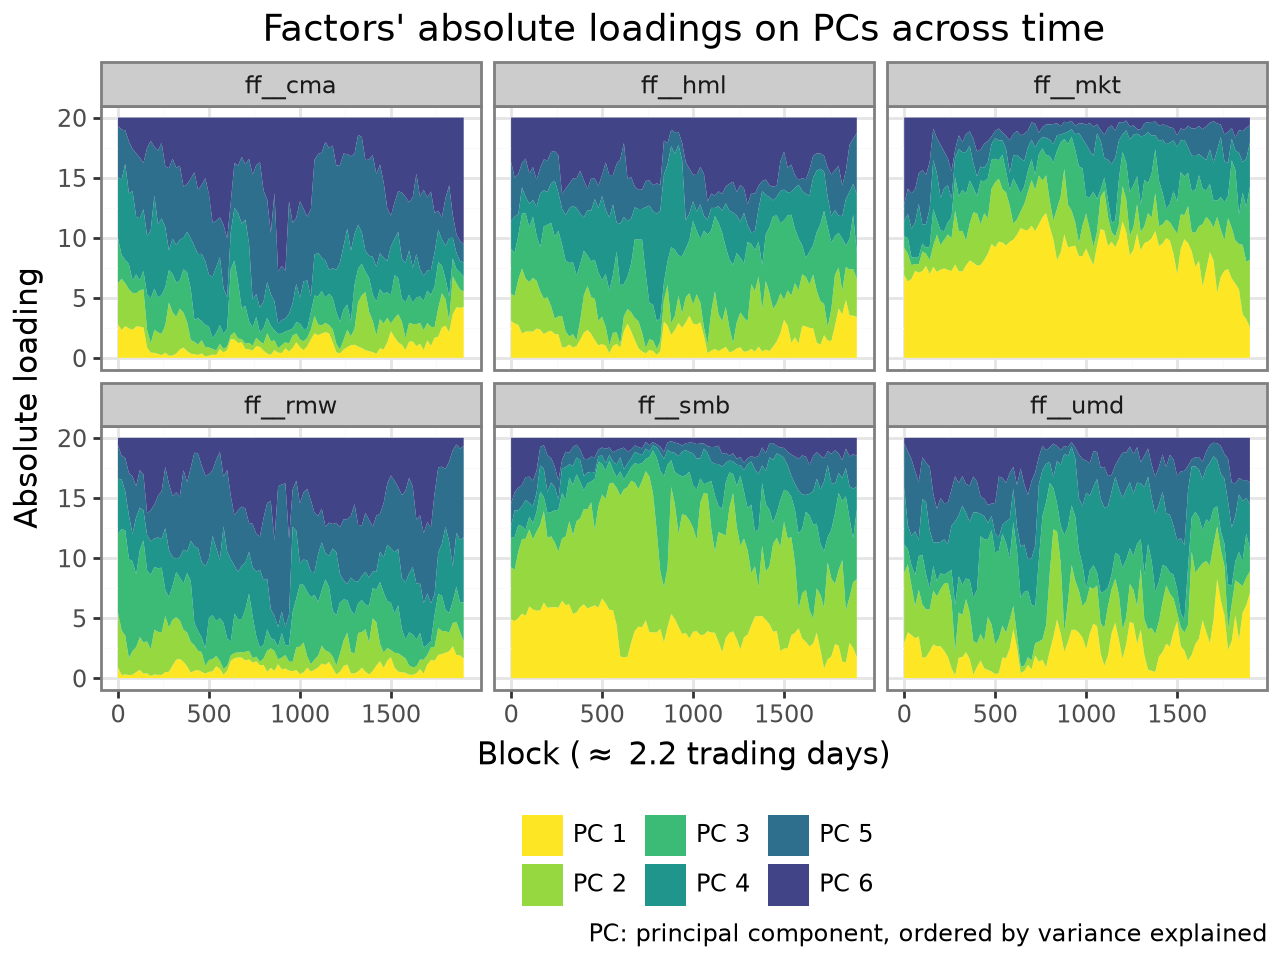

In [ ]:
plot.factor_loadings(
    data_evecs[1].with_columns(pl.col("fct").replace(cols_fct)),
    list(cols_evector.values()),
    blocks_size[1] / PARS.blocks_1min,
    exp = 1
)

Second, the principal components themselves, colored by the variance they explained at each block.

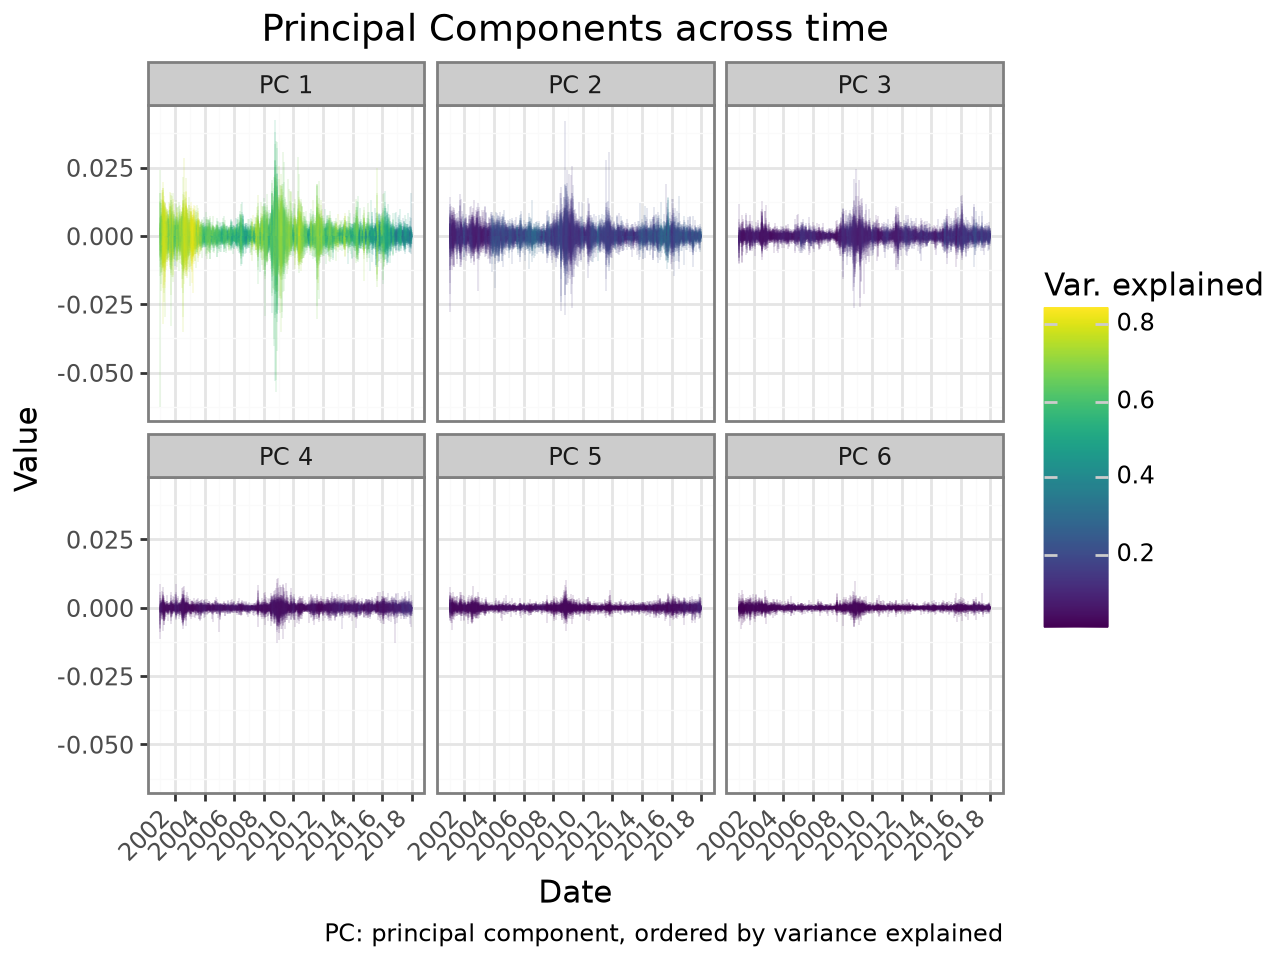

In [20]:
plot.principal_components(
    data_evals[1], data_pcs[1],
    blocks_size[1], list(cols_evalue.values()), list(cols_pc.values())
)

## Appendix {#sec-pca-app}

### Inference and spectral functions

The estimators rely on the inference for $\int_0^t \lambda(c_s) ds$. When eigenvalues can be repeated, this is non-differentiable, and the authors introduce a "trick" with spectral functions. This allows them to prove consistency and find bias-correction terms. The bias arises from the fact that eigenvalues are non-linear functions of the covariance matrix. In reality, our measure of such a matrix comes from noisy high-frequency data, and when this noise is applied to non-linear operations, it creates a bias.

In short, a spectral function $F(c_s)$ is simply a matrix function that is invariant to rotations. Associated with it is a symmetric function $(f \circ \lambda)(c_s)$ that takes the vector of eigenvalues. Studying the asymptotics of $\int_0^t F(c_s) ds$ allows the authors to prove consistency of their proposed estimators and add bias correction where needed. See the paper for more details; here, only the estimators are shown.

The authors make the four main assumptions below, although not all are needed for all results and their versions. They should be read in the context of the paper.

1. **Semimartingale Dynamics (Assumption 1):** The drift term $b_t$ is progressively measurable and locally bounded, and the spot covariance matrix $c_t$ is itself an Itô semimartingale. This standard assumption, along with limits on jump activity, ensures the underlying processes are mathematically well-behaved.
2. **Spectral Regularity for Consistency (Assumption 2):** The symmetric function $f$ (where $F = f \circ \lambda$) is continuous and satisfies a polynomial growth condition $||f(x)|| \le K(1 + ||x||^\zeta)$. This guarantees that the target integral $\int_0^t F(c_s)ds$ is strictly well-defined, making the proposed estimators consistent.
3. **Non-Crossing Eigenvalues for Inference (Assumption 3):** To establish asymptotic distributions (like standard errors via the Central Limit Theorem), different groups of eigenvalues must not cross over within the time window $[0, t]$ (i.e., $c_s \in M^*(g_1, \dots, g_r)$). This prevents non-differentiable "kinks" from forming, ensuring the eigenvalue function remains sufficiently smooth ($C^3$) so the mean-value theorem can be applied.
4. **Weakened Non-Crossing (Assumption 4):** If we only care about a specific simple eigenvalue (e.g., isolating just the 1st Principal Component), Assumption 3 can be heavily relaxed. We only need to ensure that this specific target eigenvalue does not cross its immediate neighbor (e.g., $\lambda_1(c_s) > \lambda_2(c_s)$) during $[0, t]$. The crossover behavior of the remaining eigenvalues does not matter.


### Integrated eigenvalues and eigenvectors

**Integrated vector of eigenvalues $\int_0^t \lambda_s ds$:** The estimator is a sum of the instantaneous eigenvalues, minus the bias correction term.

$$
    \hat{\lambda}_{g} = \underbrace{k_n \Delta_n \sum_{i} \hat{\lambda}_{g, ik_n\Delta_n}}_{\text{raw estimator}} ~~ - ~~ \underbrace{\Delta_n\operatorname{Tr}\left(\left(\hat{\gamma}_{g,ik_n\Delta_n}-\hat{c}_{ik_n\Delta_n}\right)^{+} \hat{c}_{ik_n\Delta_n}\right)\hat{\gamma}_{g,ik_n\Delta_n}}_{\text{bias correction}} \tag{17}
$$

**Integrated eigenvector $\int_0^t \gamma_{g,s} ds$:** The estimator is a sum of the instantaneous eigenvectors, minus the bias correction term.

$$
    \hat{\gamma}_{g} = \underbrace{k_n\Delta_n \sum_{i=0}^{[t/(k_n\Delta_n)]} \hat{\gamma}_{i_n,k_n\Delta_n}}_{\text{raw estimator}} ~~ - ~~ \underbrace{\frac{1}{2k_n}\sum_{p\neq q}\frac{\hat{\lambda}_{g,ik_n\Delta_n} \hat{\lambda}_{p,ik_n\Delta_n} \hat{\lambda}_{g,ik_n\Delta_n}}{\left(\hat{\lambda}_{g,ik_n\Delta_n}-\hat{\lambda}_{p,ik_n\Delta_n}\right)^2} \hat{\lambda}_{g,ik_n\Delta_n}}_{\text{bias correction}}
$$